# 1. Import & Load

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/My Drive/Project egression/Depression Student Dataset.csv")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Project regression/Depression Student Dataset.csv'

In [ ]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [ ]:
df["Depression"].value_counts()

,count
Depression,
Yes,252
No,250


# 2. Map Y เป็น 0/1

In [ ]:
mapping = {"Yes": 1, "No": 0}
df["Depression"] = df["Depression"].map(mapping)

In [ ]:
df["Depression"]

,Depression
0,0
1,0
2,1
3,0
4,0
...,...
497,1
498,1
499,0
500,0


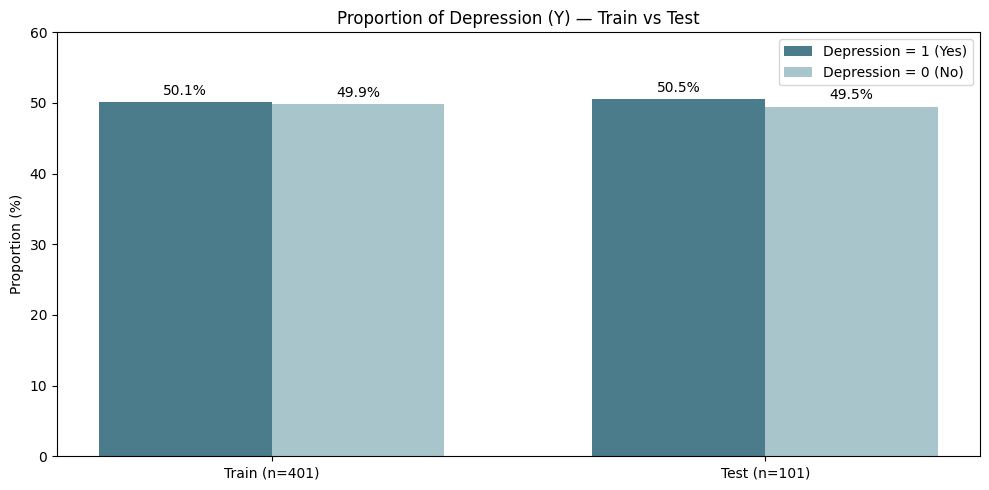

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Train (n=401)', 'Test (n=101)']
dep_1 = [50.1, 50.5]   # Depression = 1 (%)
dep_0 = [49.9, 49.5]   # Depression = 0 (%)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width/2, dep_1, width, label='Depression = 1 (Yes)', color='#4a7c8c')
ax.bar(x + width/2, dep_0, width, label='Depression = 0 (No)', color='#a9c5cc')

ax.set_ylabel('Proportion (%)')
ax.set_title('Proportion of Depression (Y) — Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 60)
ax.legend()

for i, (v1, v0) in enumerate(zip(dep_1, dep_0)):
    ax.text(i - width/2, v1 + 1, f'{v1}%', ha='center')
    ax.text(i + width/2, v0 + 1, f'{v0}%', ha='center')

plt.tight_layout()
plt.savefig('train_test_proportion.png', dpi=150)

/tmp/ipykernel_1865/6901844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="pastel")
/tmp/ipykernel_1865/6901844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="pastel")
/tmp/ipykernel_1865/6901844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="pastel")
/tmp/ipykernel_1865/6901844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

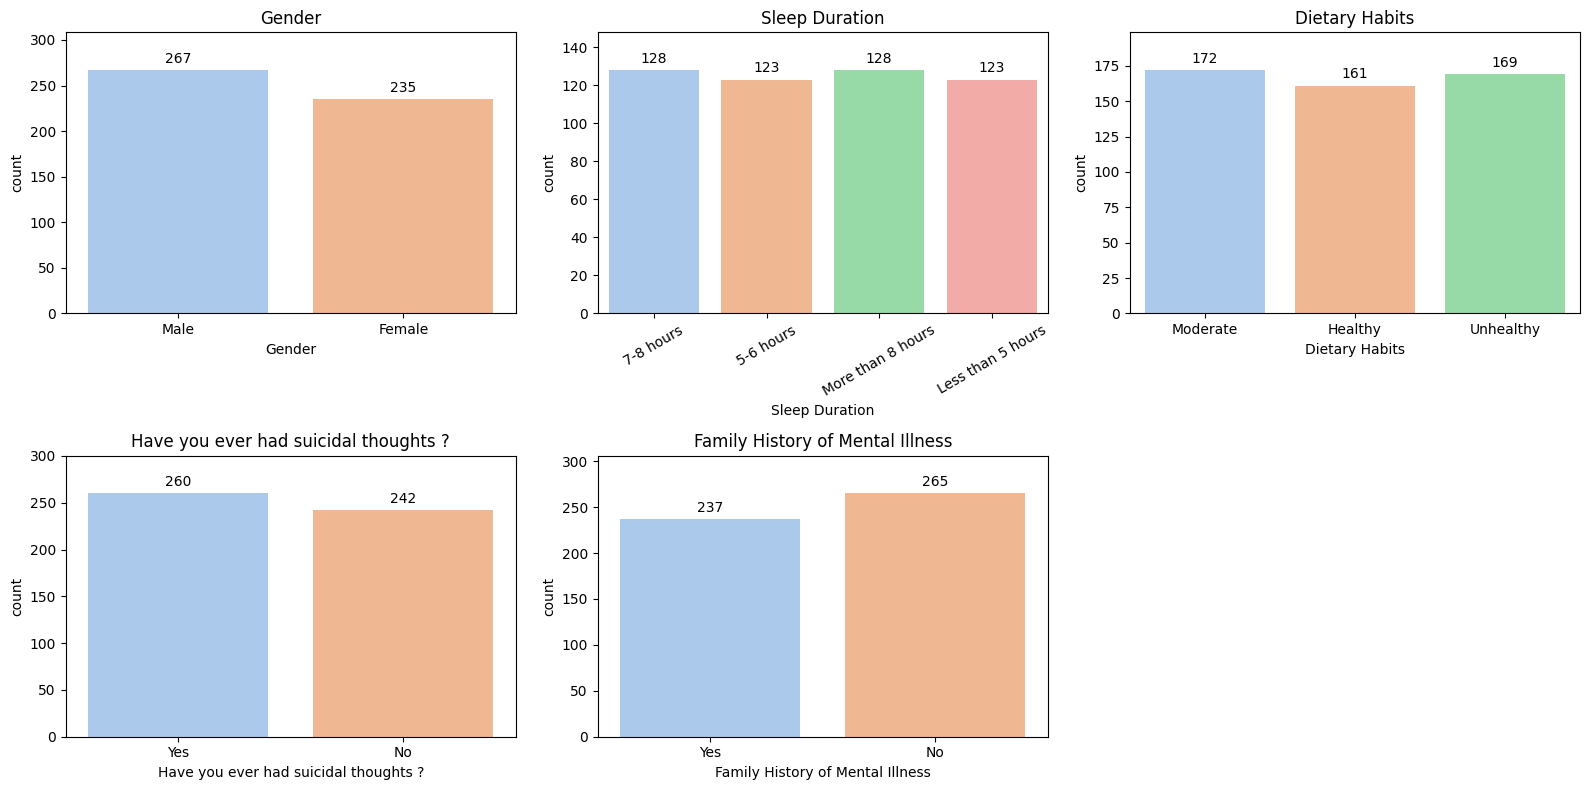

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ["Gender", "Sleep Duration", "Dietary Habits",
            "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, ax=ax, palette="pastel")
    ax.set_title(col)
    # Apply rotation only for variables with potentially long labels
    if col in ["Sleep Duration"]:
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.tick_params(axis="x", rotation=0)
    # Add counts on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1) # Adjust y-limit to make space for labels

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# 3. Train/Test Split แบบ Stratified

In [ ]:
import statsmodels.api as sm

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

In [ ]:
from sklearn.model_selection import train_test_split

* x_train_full = ทุกคอลัมน์ (ทั้งชุด) ของ train
* x_tr = x ของตัวแปรเชิงปริมาณ 1 ตัว + constant
* x_dummy = x ของตัวแปรเชิงคุณภาพ 1 ตัว หลังทำ dummy + constant
* x_selected_train = x ของโมเดลรวมสุดท้าย ที่มีหลายตัวแปรพร้อมกัน

In [ ]:
y = df["Depression"]
x_full = df.drop(columns=["Depression"])

x_train_full, x_test_full, y_train, y_test = train_test_split(
    x_full, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
print("Train shape:", x_train_full.shape)
print("Test shape:", x_test_full.shape)
print()
print("y_train proportion:")
print(y_train.value_counts(normalize=True))
print()
print("y_test proportion:")
print(y_test.value_counts(normalize=True))

Train shape: (401, 10)
Test shape: (101, 10)

y_train proportion:
Depression
1    0.501247
0    0.498753
Name: proportion, dtype: float64

y_test proportion:
Depression
1    0.50495
0    0.49505
Name: proportion, dtype: float64


# 4. Simple Logistic Regression รวมทุกตัวแปร X (คัดกรองด้วย p-value) — ตัวแปรเชิงปริมาณ

วนลูปทีละตัวแปรในเซลล์เดียว: fit บน train set (สไตล์เดียวกับอาจารย์ — `sm.Logit` + `sm.add_constant`), พิมพ์ `result.summary()` ของทุกตัวแปร,
ประเมิน F1-score บน test set (threshold 0.5) แล้วรวบรวม coefficient / p-value / F1 ของทุกตัวแปรไว้ในตารางเดียวท้ายเซลล์

**Note:** F1-score ต้องคำนวณจาก test set เพราะจุดประสงค์ของมันคือวัดว่าโมเดลทำนาย "ข้อมูลใหม่ที่ไม่เคยเห็น" ได้แม่นแค่ไหน ถ้าเอาไปคำนวณจาก train set แทน จะไม่มีความหมายเท่าที่ควร เพราะโมเดลเพิ่ง fit (เรียนรู้) จากข้อมูลชุดนั้นมาหมาดๆ มันจะทำนายแม่นเกินจริงเสมอ (ไม่ได้สะท้อนว่าเก่งจริงหรือแค่จำได้)

**เอา X แต่ละตัวมา fit แยกเป็นโมเดลของตัวเอง (Simple regression) → ดู p-value ของแต่ละตัว
คัดเอาเฉพาะตัวที่ p-value < 0.05 (section 4-6)
เอาตัวที่ผ่านมารวมกันเป็นโมเดลเดียว (Multiple regression, section 7)**

# Train (ทุกตัวแปร)

In [ ]:
num_cols = ["Age", "Academic Pressure", "Study Satisfaction", "Study Hours", "Financial Stress"]

num_results = []
fitted_models = {}   # เก็บโมเดลที่ fit เสร็จของแต่ละตัวแปรไว้ใช้ต่อในเซลล์ test

for n in num_cols:
    # เตรียม X, y ของ train (สไตล์อาจารย์: sm.add_constant ก่อน fit)
    X_tr = sm.add_constant(x_train_full[n])
    model = sm.Logit(y_train, X_tr)
    result = model.fit(disp=0)

    print(f"===== {n} =====")
    print(result.summary())
    print()

    fitted_models[n] = result

    num_results.append({
        "Variable": n,
        "Type": "Quantitative",
        "Coefficient": result.params[n],
        "p-value": result.pvalues[n],
    })

===== Age =====
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      399
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                 0.03212
Time:                        02:50:31   Log-Likelihood:                -269.02
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                 2.384e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3419      0.574      4.081      0.000       1.217       3.467
Age           -0.0889      0.021     -4.140      0.000      -0.131      -0.047

===== Academic Pressure =====
     

# Test (ทุกตัวแปร)

In [ ]:
quant_cols = ["Age", "Academic Pressure", "Study Satisfaction", "Study Hours", "Financial Stress"]

quant_results = {}

for col in quant_cols:
    # ---- TRAIN ----
    train_single = sm.add_constant(x_train_full[[col]])
    model_single = sm.Logit(y_train, train_single)
    result_single = model_single.fit(disp=0)

    # ---- TEST ----
    test_single = sm.add_constant(x_test_full[[col]], has_constant="add")

    predicted_labels = (result_single.predict(test_single) > 0.5).astype(int)
    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)

    # ---- Pseudo R-squ. จากโมเดลที่ fit ไปแล้ว (ไม่ต้อง fit ซ้ำ) ----
    pseudo_r2 = result_single.prsquared

    quant_results[col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{col}: F1 Score = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Age: F1 Score = 0.6154, Accuracy = 0.6040, Pseudo R-squ. = 0.0321
Academic Pressure: F1 Score = 0.7544, Accuracy = 0.7228, Pseudo R-squ. = 0.1690
Study Satisfaction: F1 Score = 0.6429, Accuracy = 0.6040, Pseudo R-squ. = 0.0669
Study Hours: F1 Score = 0.6226, Accuracy = 0.6040, Pseudo R-squ. = 0.0287
Financial Stress: F1 Score = 0.6786, Accuracy = 0.6436, Pseudo R-squ. = 0.0674


In [ ]:
for row in num_results:
    n = row["Variable"]
    result = fitted_models[n]   # ใช้โมเดลที่ train ไว้แล้วจากเซลล์ก่อนหน้า ไม่ fit ใหม่

    # ทำนายบน test set แล้วคำนวณ F1-score ที่ threshold 0.5
    X_te = sm.add_constant(x_test_full[n])
    probabilities = result.predict(X_te)
    predicted_labels = (probabilities > 0.5).astype(int)
    f1 = f1_score(y_test, predicted_labels)

    print(f"{n}: F1 Score: {f1:.4f}")

    row["F1-score"] = f1

Age: F1 Score: 0.6154
Academic Pressure: F1 Score: 0.7544
Study Satisfaction: F1 Score: 0.6429
Study Hours: F1 Score: 0.6226
Financial Stress: F1 Score: 0.6786


In [ ]:
quant_screening_table = pd.DataFrame(num_results)
quant_screening_table["ผ่านเกณฑ์ (p<0.05)"] = quant_screening_table["p-value"] < 0.05
quant_screening_table = quant_screening_table.sort_values("p-value").reset_index(drop=True)
quant_screening_table

,Variable,Type,Coefficient,p-value,F1-score,ผ่านเกณฑ์ (p<0.05)
0,Academic Pressure,Quantitative,0.796681,8.069547e-18,0.754386,True
1,Financial Stress,Quantitative,0.450096,4.301876e-09,0.678571,True
2,Study Satisfaction,Quantitative,-0.460628,5.054962e-09,0.642857,True
3,Age,Quantitative,-0.088894,3.474648e-05,0.615385,True
4,Study Hours,Quantitative,0.108985,8.707562e-05,0.622642,True


# 5. Simple Logistic Regression ทีละตัวแปร — ตัวแปรเชิงคุณภาพ (Dummy)

ตามแพทเทิร์นของอาจารย์ (เหมือนตอนทำ `Race` ในไฟล์ตัวอย่าง): `pd.get_dummies(..., drop_first=True)` แล้ว `.astype(int)`

# Gender

In [ ]:
# ========== TRAIN: สร้างและ fit โมเดลจาก train set ==========

# แปลง Gender (train) ให้เป็น dummy variable
train_dummy = pd.get_dummies(x_train_full["Gender"], prefix="Gender", drop_first=True)

# เติมคอลัมน์ constant (intercept)
train_dummy = sm.add_constant(train_dummy)

train_dummy.head()

,const,Gender_Male
171,1.0,True
236,1.0,False
36,1.0,False
430,1.0,True
146,1.0,True


In [ ]:
# แปลง dtype เป็น int ให้ statsmodels ใช้งานได้
train_dummy = train_dummy.astype(int)
train_dummy.head()

,const,Gender_Male
171,1,1
236,1,0
36,1,0
430,1,1
146,1,1


In [ ]:
# fit โมเดล logistic regression ด้วยข้อมูล train
model = sm.Logit(y_train, train_dummy)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.692894
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      399
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:               0.0003606
Time:                        02:50:31   Log-Likelihood:                -277.85
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                    0.6543
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0417      0.144     -0.289      0.773      -0.325       0.241
Gender_Male     0.0895      0.200      0.448      0.654      -0.302       0.481
===============================================================================
"""

In [ ]:
# ===== Gender: per-level F1, Accuracy, Pseudo R-squ. (สร้าง dummy แยก) =====
gender_train_dummy = pd.get_dummies(x_train_full[["Gender"]], prefix="Gender", drop_first=True).astype(int)
gender_test_dummy  = pd.get_dummies(x_test_full[["Gender"]],  prefix="Gender", drop_first=True).astype(int)

gender_dummy_cols = gender_train_dummy.columns.tolist()
gender_results = {}

for col in gender_dummy_cols:
    X_train_single = sm.add_constant(gender_train_dummy[[col]])
    result_single = sm.Logit(y_train, X_train_single).fit(disp=0)

    X_test_single = (
        gender_test_dummy[[col]]
        .reindex(columns=[col], fill_value=0)
        .pipe(sm.add_constant, has_constant="add")
        .astype(int)
    )
    pred_prob = result_single.predict(X_test_single)
    predicted_labels = (pred_prob >= 0.5).astype(int)

    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)
    pseudo_r2 = result_single.prsquared

    gender_results[col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{col}: F1 = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Gender_Male: F1 = 0.5688, Accuracy = 0.5347, Pseudo R-squ. = 0.0004


# Sleep Duration

In [ ]:
# แปลง Sleep Duration (train) ให้เป็น dummy variable
train_dummy = pd.get_dummies(x_train_full["Sleep Duration"], prefix="Sleep Duration", drop_first=True)
train_dummy = sm.add_constant(train_dummy)
train_dummy.head()

,const,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours
171,1.0,False,True,False
236,1.0,False,True,False
36,1.0,False,True,False
430,1.0,False,False,True
146,1.0,False,False,False


In [ ]:
# แปลง dtype เป็น int ให้ statsmodels ใช้งานได้
train_dummy = train_dummy.astype(int)
train_dummy.head()

,const,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours
171,1,0,1,0
236,1,0,1,0
36,1,0,1,0
430,1,0,0,1
146,1,0,0,0


In [ ]:
# fit โมเดล logistic regression ด้วยข้อมูล train
model = sm.Logit(y_train, train_dummy)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.691674
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            3
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                0.002120
Time:                        02:50:31   Log-Likelihood:                -277.36
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                    0.7581
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                0.0211      0.205      0.103      0.918      -0.381       0.423
Sleep Duration_7-8 hours             0.0800      0.287      0.278      0.781      -0.483       0.643
Sleep Duration_Less than 5 hours     0.0590      0.287      0.206      0.837      -0.503       0.621
Sleep Duration_More than 8 hours    -0.1897      0.282     -0.672      0.502      -0.743       0.364
====================================================================================================
"""

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import f1_score, accuracy_score

# ===== Sleep Duration: per-level F1, Accuracy, Pseudo R-squ. =====
sleep_results = {}

# Generate dummy variables for Sleep Duration from full train/test sets
x_train_dummy = pd.get_dummies(x_train_full["Sleep Duration"], prefix="Sleep Duration", drop_first=True).astype(int)
x_test_dummy = pd.get_dummies(x_test_full["Sleep Duration"], prefix="Sleep Duration", drop_first=True).astype(int)

sleep_dummy_cols = x_train_dummy.columns.tolist() # Define sleep_dummy_cols here

for col in sleep_dummy_cols:  # dummy columns ของ Sleep Duration
    X_train_single = sm.add_constant(x_train_dummy[[col]])
    result_single = sm.Logit(y_train, X_train_single).fit(disp=0)

    X_test_single = (
        x_test_dummy[[col]]
        .reindex(columns=[col], fill_value=0)
        .pipe(sm.add_constant, has_constant="add")
        .astype(int)
    )
    pred_prob = result_single.predict(X_test_single)
    predicted_labels = (pred_prob >= 0.5).astype(int)

    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)
    pseudo_r2 = result_single.prsquared

    sleep_results[col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{col}: F1 = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Sleep Duration_7-8 hours: F1 = 0.3750, Accuracy = 0.5050, Pseudo R-squ. = 0.0005
Sleep Duration_Less than 5 hours: F1 = 0.3243, Accuracy = 0.5050, Pseudo R-squ. = 0.0003
Sleep Duration_More than 8 hours: F1 = 0.6565, Accuracy = 0.5545, Pseudo R-squ. = 0.0020


# Dietary Habits

In [ ]:
# แปลง Dietary Habits (train) ให้เป็น dummy variable
train_dummy = pd.get_dummies(x_train_full["Dietary Habits"], prefix="Dietary Habits", drop_first=True)
train_dummy = sm.add_constant(train_dummy)
train_dummy.head()

,const,Dietary Habits_Moderate,Dietary Habits_Unhealthy
171,1.0,False,True
236,1.0,False,True
36,1.0,False,False
430,1.0,False,False
146,1.0,False,False


In [ ]:
# แปลง dtype เป็น int ให้ statsmodels ใช้งานได้
train_dummy = train_dummy.astype(int)
train_dummy.head()

,const,Dietary Habits_Moderate,Dietary Habits_Unhealthy
171,1,0,1
236,1,0,1
36,1,0,0
430,1,0,0
146,1,0,0


In [ ]:
# fit โมเดล logistic regression ด้วยข้อมูล train
model = sm.Logit(y_train, train_dummy)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.669747
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      398
Method:                           MLE   Df Model:                            2
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                 0.03376
Time:                        02:50:32   Log-Likelihood:                -268.57
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                 8.419e-05
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.5715      0.181     -3.165      0.002      -0.925      -0.218
Dietary Habits_Moderate      0.6467      0.250      2.582      0.010       0.156       1.138
Dietary Habits_Unhealthy     1.0704      0.253      4.228      0.000       0.574       1.567
============================================================================================
"""

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

diet_dummy_cols = pd.get_dummies(
    x_train_full["Dietary Habits"], prefix="Dietary Habits", drop_first=True
).columns.tolist()

diet_results = {}

for dummy_col in diet_dummy_cols:
    # ---- TRAIN ----
    train_single_dummy = pd.get_dummies(
        x_train_full["Dietary Habits"], prefix="Dietary Habits", drop_first=True
    )[[dummy_col]]
    train_single_dummy = sm.add_constant(train_single_dummy).astype(int)

    model_single = sm.Logit(y_train, train_single_dummy)
    result_single = model_single.fit(disp=0)

    # ---- TEST ----
    test_single_dummy = (
        pd.get_dummies(x_test_full["Dietary Habits"], prefix="Dietary Habits", drop_first=True)
        .reindex(columns=[dummy_col], fill_value=0)
        .pipe(sm.add_constant, has_constant="add")
        .astype(int)
    )

    predicted_labels = (result_single.predict(test_single_dummy) > 0.5).astype(int)
    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)

    # ---- Pseudo R-squ. จากโมเดลที่ fit ไปแล้ว (ไม่ต้อง fit ซ้ำ) ----
    pseudo_r2 = result_single.prsquared

    diet_results[dummy_col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{dummy_col}: F1 Score = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Dietary Habits_Moderate: F1 Score = 0.2889, Accuracy = 0.3663, Pseudo R-squ. = 0.0004
Dietary Habits_Unhealthy: F1 Score = 0.5176, Accuracy = 0.5941, Pseudo R-squ. = 0.0216


# Have you ever had suicidal thoughts ?

In [ ]:
# แปลง Have you ever had suicidal thoughts ? (train) ให้เป็น dummy variable
train_dummy = pd.get_dummies(x_train_full["Have you ever had suicidal thoughts ?"], prefix="Suicidal", drop_first=True)
train_dummy = sm.add_constant(train_dummy)
train_dummy.head()

,const,Suicidal_Yes
171,1.0,True
236,1.0,False
36,1.0,False
430,1.0,False
146,1.0,False


In [ ]:
# แปลง dtype เป็น int ให้ statsmodels ใช้งานได้
train_dummy = train_dummy.astype(int)
train_dummy.head()

,const,Suicidal_Yes
171,1,1
236,1,0
36,1,0
430,1,0
146,1,0


In [ ]:
# fit โมเดล logistic regression ด้วยข้อมูล train
model = sm.Logit(y_train, train_dummy)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.579940
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      399
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                  0.1633
Time:                        02:50:32   Log-Likelihood:                -232.56
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                 1.598e-21
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.0508      0.164     -6.396      0.000      -1.373      -0.729
Suicidal_Yes     2.0251      0.226      8.953      0.000       1.582       2.468
================================================================================
"""

In [ ]:
suicidal_dummy_cols = pd.get_dummies(
    x_train_full["Have you ever had suicidal thoughts ?"], prefix="Suicidal", drop_first=True
).columns.tolist()

suicidal_results = {}

for dummy_col in suicidal_dummy_cols:
    # ---- TRAIN ----
    train_single_dummy = pd.get_dummies(
        x_train_full["Have you ever had suicidal thoughts ?"], prefix="Suicidal", drop_first=True
    )[[dummy_col]]
    train_single_dummy = sm.add_constant(train_single_dummy).astype(int)

    model_single = sm.Logit(y_train, train_single_dummy)
    result_single = model_single.fit(disp=0)

    # ---- TEST ----
    test_single_dummy = (
        pd.get_dummies(x_test_full["Have you ever had suicidal thoughts ?"], prefix="Suicidal", drop_first=True)
        .reindex(columns=[dummy_col], fill_value=0)
        .pipe(sm.add_constant, has_constant="add")
        .astype(int)
    )

    predicted_labels = (result_single.predict(test_single_dummy) > 0.5).astype(int)
    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)

    # ---- Pseudo R-squ. จากโมเดลที่ fit ไปแล้ว (ไม่ต้อง fit ซ้ำ) ----
    pseudo_r2 = result_single.prsquared

    suicidal_results[dummy_col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{dummy_col}: F1 Score = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Suicidal_Yes: F1 Score = 0.7379, Accuracy = 0.7327, Pseudo R-squ. = 0.1633


# Family History of Mental Illness

In [ ]:
# แปลง Family History of Mental Illness (train) ให้เป็น dummy variable
train_dummy = pd.get_dummies(x_train_full["Family History of Mental Illness"], prefix="Family History of Mental Illness", drop_first=True)
train_dummy = sm.add_constant(train_dummy)
train_dummy.head()

,const,Family History of Mental Illness_Yes
171,1.0,True
236,1.0,True
36,1.0,False
430,1.0,True
146,1.0,True


In [ ]:
# แปลง dtype เป็น int ให้ statsmodels ใช้งานได้
train_dummy = train_dummy.astype(int)
train_dummy.head()

,const,Family History of Mental Illness_Yes
171,1,1
236,1,1
36,1,0
430,1,1
146,1,1


In [ ]:
# fit โมเดล logistic regression ด้วยข้อมูล train
model = sm.Logit(y_train, train_dummy)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.692232
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      399
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                0.001317
Time:                        02:50:32   Log-Likelihood:                -277.58
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                    0.3923
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.0741      0.136     -0.544      0.586      -0.341       0.193
Family History of Mental Illness_Yes     0.1715      0.201      0.855      0.392      -0.222       0.565
========================================================================================================
"""

In [ ]:
family_dummy_cols = pd.get_dummies(
    x_train_full["Family History of Mental Illness"], prefix="Family History of Mental Illness", drop_first=True
).columns.tolist()

family_results = {}

for dummy_col in family_dummy_cols:
    # ---- TRAIN ----
    train_single_dummy = pd.get_dummies(
        x_train_full["Family History of Mental Illness"], prefix="Family History of Mental Illness", drop_first=True
    )[[dummy_col]]
    train_single_dummy = sm.add_constant(train_single_dummy).astype(int)

    model_single = sm.Logit(y_train, train_single_dummy)
    result_single = model_single.fit(disp=0)

    # ---- TEST ----
    test_single_dummy = (
        pd.get_dummies(x_test_full["Family History of Mental Illness"], prefix="Family History of Mental Illness", drop_first=True)
        .reindex(columns=[dummy_col], fill_value=0)
        .pipe(sm.add_constant, has_constant="add")
        .astype(int)
    )

    predicted_labels = (result_single.predict(test_single_dummy) > 0.5).astype(int)
    f1 = f1_score(y_test, predicted_labels)
    acc = accuracy_score(y_test, predicted_labels)

    # ---- Pseudo R-squ. จากโมเดลที่ fit ไปแล้ว (ไม่ต้อง fit ซ้ำ) ----
    pseudo_r2 = result_single.prsquared

    family_results[dummy_col] = {"F1": f1, "Accuracy": acc, "Pseudo R-squ.": pseudo_r2}
    print(f"{dummy_col}: F1 Score = {f1:.4f}, Accuracy = {acc:.4f}, Pseudo R-squ. = {pseudo_r2:.4f}")

Family History of Mental Illness_Yes: F1 Score = 0.5631, Accuracy = 0.5545, Pseudo R-squ. = 0.0013


In [ ]:
cols = ["Gender", "Family History of Mental Illness", "Have you ever had suicidal thoughts ?", "Dietary Habits", "Sleep Duration"]

for col in cols:
    print(f"\n===== {col} =====")
    unique_vals = pd.Series(sorted(x_train_full[col].dropna().unique()), name=col)
    mapping = pd.get_dummies(unique_vals, prefix=col, drop_first=True).astype(int)
    result = pd.concat([unique_vals, mapping], axis=1)
    print(result.to_string(index=False))


===== Gender =====
Gender  Gender_Male
Female            0
  Male            1

===== Family History of Mental Illness =====
Family History of Mental Illness  Family History of Mental Illness_Yes
                              No                                     0
                             Yes                                     1

===== Have you ever had suicidal thoughts ? =====
Have you ever had suicidal thoughts ?  Have you ever had suicidal thoughts ?_Yes
                                   No                                          0
                                  Yes                                          1

===== Dietary Habits =====
Dietary Habits  Dietary Habits_Moderate  Dietary Habits_Unhealthy
       Healthy                        0                         0
      Moderate                        1                         0
     Unhealthy                        0                         1

===== Sleep Duration =====
   Sleep Duration  Sleep Duration_7-8 hours  Sl

# 6. รวมผล p-value ของทุกตัวแปรเป็นตารางเดียว แล้วคัดตามเกณฑ์

เกณฑ์: เก็บตัวแปรที่ p-value < 0.05 (ระดับนัยสำคัญ) ไว้ใช้ในโมเดลรวม

In [ ]:
# นำผล p-value ของตัวแปรเชิงปริมาณจากหัวข้อ 4 มาใช้ต่อ (ไม่ fit ซ้ำ)
# + แยกทุก dummy level ของตัวแปรเชิงคุณภาพเป็นแถวของตัวเอง (ไม่รวมเป็นตัวแทนเดียว)
results_detailed = [
    {"Variable": r["Variable"], "Type": r["Type"], "p-value": r["p-value"]}
    for r in num_results
]

for col, prefix in [
    ("Gender", "Gender"),
    ("Sleep Duration", "Sleep Duration"),
    ("Dietary Habits", "Dietary Habits"),
    ("Have you ever had suicidal thoughts ?", "Suicidal"),
    ("Family History of Mental Illness", "Family History of Mental Illness"),
]:
    train_dummy = pd.get_dummies(x_train_full[col], prefix=prefix, drop_first=True)
    train_dummy = sm.add_constant(train_dummy).astype(int)
    r = sm.Logit(y_train, train_dummy).fit(disp=0)
    # เก็บ p-value ของทุก dummy level แยกเป็นแถวของตัวเอง
    dummy_pvals = r.pvalues.drop("const")
    for dummy_name, pval in dummy_pvals.items():
        results_detailed.append({"Variable": dummy_name, "Type": "Qualitative", "p-value": pval})

results_table_detailed = pd.DataFrame(results_detailed)
results_table_detailed["ผ่านเกณฑ์ (p<0.05)"] = results_table_detailed["p-value"] < 0.05
results_table_detailed = results_table_detailed.sort_values("p-value").reset_index(drop=True)

# แปลง p-value จาก scientific notation ให้เป็นทศนิยมอ่านง่าย
results_table_detailed["p-value"] = results_table_detailed["p-value"].apply(
    lambda p: "< 0.001" if p < 0.001 else f"{p:.4f}"
)

results_table_detailed

,Variable,Type,p-value,ผ่านเกณฑ์ (p<0.05)
0,Suicidal_Yes,Qualitative,< 0.001,True
1,Academic Pressure,Quantitative,< 0.001,True
2,Financial Stress,Quantitative,< 0.001,True
3,Study Satisfaction,Quantitative,< 0.001,True
4,Dietary Habits_Unhealthy,Qualitative,< 0.001,True
5,Age,Quantitative,< 0.001,True
6,Study Hours,Quantitative,< 0.001,True
7,Dietary Habits_Moderate,Qualitative,0.0098,True
8,Family History of Mental Illness_Yes,Qualitative,0.3925,False
9,Sleep Duration_More than 8 hours,Qualitative,0.5018,False


In [ ]:
results_vars = results_table_detailed.loc[results_table_detailed["ผ่านเกณฑ์ (p<0.05)"], "Variable"].tolist()
print("ตัวแปรที่ผ่านเกณฑ์ p-value < 0.05:")
results_vars

ตัวแปรที่ผ่านเกณฑ์ p-value < 0.05:


['Suicidal_Yes',
 'Academic Pressure',
 'Financial Stress',
 'Study Satisfaction',
 'Dietary Habits_Unhealthy',
 'Age',
 'Study Hours',
 'Dietary Habits_Moderate']

# 7. Multiple Logistic Regression ด้วยตัวแปรที่ผ่านเกณฑ์

ลอง X ทีละตัวแล้วดู p-value คัดตัวที่มีนัยสำคัญไว้ "ขั้นต่อไปจะใช้ X1, X2, ..., X10 → สร้างตัวแบบ logistic" — คือให้เอาตัวที่ผ่านเกณฑ์ทั้งหมดมารวมเป็นโมเดลเดียว

In [ ]:
quant_selected = [v for v in results_vars if v in num_cols]
qual_selected = [v for v in results_vars if v not in num_cols]

qual_prefix_map = {
    "Gender": "Gender",
    "Sleep Duration": "Sleep Duration",
    "Dietary Habits": "Dietary Habits",
    "Have you ever had suicidal thoughts ?": "Suicidal",
    "Family History of Mental Illness": "Family History of Mental Illness",
}

parts_multiple_train = [x_train_full[quant_selected]] if quant_selected else []

# Collect all dummy columns that need to be in x_multiple_train
all_dummy_cols_to_add = pd.DataFrame(index=x_train_full.index)

# Iterate over the original categorical columns
for original_col_name, prefix_val in qual_prefix_map.items():
    # Generate all possible dummy columns for this original categorical variable
    generated_dummies = pd.get_dummies(x_train_full[original_col_name], prefix=prefix_val, drop_first=True)

    # Filter generated_dummies to include only those that are in qual_selected
    # This ensures we only add significant dummy levels
    relevant_dummy_columns = [dummy_col for dummy_col in generated_dummies.columns if dummy_col in qual_selected]

    if relevant_dummy_columns:
        all_dummy_cols_to_add = pd.concat([all_dummy_cols_to_add, generated_dummies[relevant_dummy_columns]], axis=1)

if not all_dummy_cols_to_add.empty:
    parts_multiple_train.append(all_dummy_cols_to_add)

x_multiple_train = pd.concat(parts_multiple_train, axis=1).astype(float)
x_multiple_train = sm.add_constant(x_multiple_train)
x_multiple_train.head()

,const,Academic Pressure,Financial Stress,Study Satisfaction,Age,Study Hours,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Suicidal_Yes
171,1.0,2.0,4.0,4.0,33.0,12.0,0.0,1.0,1.0
236,1.0,1.0,5.0,5.0,18.0,11.0,0.0,1.0,0.0
36,1.0,1.0,2.0,1.0,22.0,2.0,0.0,0.0,0.0
430,1.0,3.0,1.0,2.0,28.0,3.0,0.0,0.0,0.0
146,1.0,5.0,2.0,3.0,29.0,11.0,0.0,0.0,0.0


In [ ]:
model = sm.Logit(y_train, x_multiple_train)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.109612
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Depression   No. Observations:                  401
Model:                          Logit   Df Residuals:                      392
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                  0.8419
Time:                        02:50:32   Log-Likelihood:                -43.955
converged:                       True   LL-Null:                       -277.95
Covariance Type:            nonrobust   LLR p-value:                 5.150e-96
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -4.4470      2.283     -1.948      0.051      -8.921       0.027
Academic Pressure            3.5421      0.559      6.334      0.000       2.446       4.638
Financial Stress             2.2305      0.380      5.868      0.000       1.485       2.976
Study Satisfaction          -2.0795      0.345     -6.031      0.000      -2.755      -1.404
Age                         -0.6641      0.116     -5.744      0.000      -0.891      -0.438
Study Hours                  0.6518      0.120      5.412      0.000       0.416       0.888
Dietary Habits_Moderate      1.8997      0.750      2.533      0.011       0.430       3.369
Dietary Habits_Unhealthy     3.6994      0.849      4.358      0.000       2.035       5.363
Suicidal_Yes                 9.9225      1.519      6.533      0.000       6.945      12.900
============================================================================================

Possibly complete quasi-separation: A fraction 0.37 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [ ]:
from sklearn.metrics import f1_score

f1_full_model = f1_score(y_test, predicted_labels)
print(f"F1-score ของ Multiple Logistic Regression (โมเดลรวม): {f1_full_model:.4f}")

F1-score ของ Multiple Logistic Regression (โมเดลรวม): 0.5631


**หมายเหตุสำคัญ:** statsmodels แจ้งเตือน *"Possibly complete quasi-separation"* ใน summary ด้านบน
หมายความว่าตัวแปรต้นที่เลือกมา (โดยเฉพาะ `Have you ever had suicidal thoughts ?`) สามารถแยกกลุ่ม Depression Yes/No ได้เกือบสมบูรณ์แบบ
ทำให้ค่า coefficient / odds ratio บางตัวถูกประเมินสูงเกินจริง (inflated) และ standard error ไม่แม่นยำนัก
ต้องเล่าประเด็นนี้ตอนนำเสนอ (เป็นส่วนหนึ่งของการเช็ค assumption) — ดูรายละเอียดเพิ่มเติมในหัวข้อ 10

# 8. ประเมินโมเดลรวมบน Test set ด้วย Confusion Matrix ครบชุด

In [ ]:
parts_test = [x_test_full[quant_selected]] if quant_selected else []

# Collect all dummy columns for the test set, matching the structure of x_multiple_train
all_dummy_cols_to_add_test = pd.DataFrame(index=x_test_full.index)

# Iterate over the original categorical column names that might have significant dummies
for original_col_name, prefix_val in qual_prefix_map.items():
    # Generate all possible dummy columns for this original categorical variable in the test set
    generated_dummies_test = pd.get_dummies(x_test_full[original_col_name], prefix=prefix_val, drop_first=True)

    # Filter generated_dummies_test to include only those that are in qual_selected
    relevant_dummy_columns_test = [dummy_col for dummy_col in generated_dummies_test.columns if dummy_col in qual_selected]

    if relevant_dummy_columns_test:
        # Concatenate only the relevant dummy columns
        all_dummy_cols_to_add_test = pd.concat([all_dummy_cols_to_add_test, generated_dummies_test[relevant_dummy_columns_test]], axis=1)

if not all_dummy_cols_to_add_test.empty:
    parts_test.append(all_dummy_cols_to_add_test)

X_selected_test = pd.concat(parts_test, axis=1).astype(float)
# The column order is important for prediction, so match it to x_multiple_train's non-constant columns.
# x_multiple_train already includes 'const', so we drop it for reindexing and then re-add.
model_columns_without_const = x_multiple_train.columns.drop("const")
X_selected_test = X_selected_test.reindex(columns=model_columns_without_const, fill_value=0)
X_selected_test = sm.add_constant(X_selected_test, has_constant="add")

probabilities = result.predict(X_selected_test)
predicted_labels = (probabilities > 0.5).astype(int)

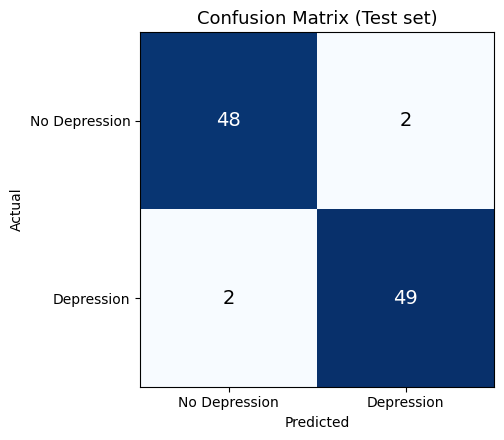

Classification Report:
               precision    recall  f1-score   support

No Depression       0.96      0.96      0.96        50
   Depression       0.96      0.96      0.96        51

     accuracy                           0.96       101
    macro avg       0.96      0.96      0.96       101
 weighted avg       0.96      0.96      0.96       101



In [ ]:
# ===== วาด Confusion Matrix เป็นกราฟ heatmap =====
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")

labels_cm = ["No Depression", "Depression"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels_cm)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels_cm)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test set)", fontsize=13)

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt_color = "white" if val > cm.max() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=14, color=txt_color)

plt.tight_layout()
plt.show()

# ===== Classification Report =====
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, predicted_labels, target_names=["No Depression", "Depression"]))

In [ ]:
cm_table = pd.DataFrame(
    cm,
    index=["Actual: No Depression (0)", "Actual: Depression (1)"],
    columns=["Predicted: No Depression (0)", "Predicted: Depression (1)"]
)
cm_table

,Predicted: No Depression (0),Predicted: Depression (1)
Actual: No Depression (0),48,2
Actual: Depression (1),2,49


# 9. แปลผล Coefficient -> Odds Ratio -> % change in odds
สูตร: `% change in odds = 100 * (e^coef - 1)`

In [ ]:
# odds_ratio = np.exp(result.params)
# pct_change_odds = 100 * (np.exp(result.params) - 1)

# interpretation_table = pd.DataFrame({
#     "Coefficient": result.params,
#     "Odds Ratio": odds_ratio,
#     "% change in odds": pct_change_odds,
#     "p-value": result.pvalues
# })
# interpretation_table = interpretation_table.drop("const")
# interpretation_table["นัยสำคัญ (p<0.05)"] = interpretation_table["p-value"] < 0.05
# interpretation_table.sort_values("p-value")

# 10. ตรวจสอบ

1. **Y ต้องเป็น binary (Bernoulli)** — ตรวจแล้วว่า `Depression` มีเพียง 2 ค่า (Yes/No)
2. **ความสัมพันธ์เชิงเส้นตรงระหว่าง log-odds กับตัวแปรต้นเชิงปริมาณ** — ประเมินผ่าน Confusion Matrix แทนการตรวจแบบเป็นทางการ (ตามสไลด์หน้า 18)
3. **สัดส่วน Class ของ Y ไม่ imbalance รุนแรง** — ตรวจสอบด้านล่าง
4. **ใช้ Stratified Sampling ในการแบ่ง train/test** — ทำแล้วในหัวข้อ 4.3
5. **ตรวจ p-value ของทุกตัวแปร** เทียบกับระดับนัยสำคัญ 0.05 — ทำแล้วในหัวข้อ 4.6
6. **ตรวจสอบ (Quasi-)Complete Separation** — เนื่องจาก statsmodels แจ้งเตือนในหัวข้อ 4.7 ว่ามี possibly complete quasi-separation ต้องตรวจสอบและอธิบายผลกระทบต่อความน่าเชื่อถือของ coefficient/odds ratio

In [ ]:
# 6) ตรวจสอบ (quasi-)complete separation อย่างเป็นรูปธรรม
# ถ้าตัวแปรต้นตัวใดตัวหนึ่งสามารถแยก Y ได้เกือบสมบูรณ์ จะทำให้ coefficient ประเมินได้ไม่นิ่ง (inflated)
check = pd.crosstab(x_train_full["Have you ever had suicidal thoughts ?"], y_train)
print("Crosstab: Suicidal thoughts vs Depression (train set)")
print(check)
print()
print("=> ตัวแปรนี้แยกกลุ่ม Depression ได้เกือบสมบูรณ์แบบ จึงเป็นสาเหตุของคำเตือน quasi-separation")
print("=> ผลคือ Odds Ratio ของตัวแปรนี้ในตาราง 4.9 อาจสูงเกินจริง ควรตีความอย่างระมัดระวัง")
print("   และเน้นเล่าทิศทาง (บวก/ลบ) มากกว่าเน้นขนาดตัวเลขตรง ๆ ตอนนำเสนอ")

Crosstab: Suicidal thoughts vs Depression (train set)
Depression                               0    1
Have you ever had suicidal thoughts ?          
No                                     143   50
Yes                                     57  151

=> ตัวแปรนี้แยกกลุ่ม Depression ได้เกือบสมบูรณ์แบบ จึงเป็นสาเหตุของคำเตือน quasi-separation
=> ผลคือ Odds Ratio ของตัวแปรนี้ในตาราง 4.9 อาจสูงเกินจริง ควรตีความอย่างระมัดระวัง
   และเน้นเล่าทิศทาง (บวก/ลบ) มากกว่าเน้นขนาดตัวเลขตรง ๆ ตอนนำเสนอ


In [ ]:
# 1) ตรวจว่า Y เป็น binary จริง
print("Unique values of Depression:", df["Depression"].unique())

Unique values of Depression: [0 1]


In [ ]:
# 3) ตรวจสัดส่วน class เพื่อดู imbalance
class_ratio = df["Depression"].value_counts(normalize=True)
print(class_ratio)

if class_ratio.min() < 0.2:
    print("\n=> ข้อมูล imbalance ค่อนข้างมาก ควรพิจารณา Oversampling/Undersampling")
else:
    print("\n=> สัดส่วน Class ใกล้เคียงกัน (ไม่ imbalance รุนแรง) ไม่จำเป็นต้องทำ Oversampling/Undersampling")

Depression
1    0.501992
0    0.498008
Name: proportion, dtype: float64

=> สัดส่วน Class ใกล้เคียงกัน (ไม่ imbalance รุนแรง) ไม่จำเป็นต้องทำ Oversampling/Undersampling


In [ ]:
# 4) ยืนยันว่าสัดส่วน class ใน train/test ใกล้เคียงกับ raw data (ผลจาก stratified split)
print("Raw data:")
print(df["Depression"].value_counts(normalize=True))
print()
print("Train set:")
print(y_train.value_counts(normalize=True))
print()
print("Test set:")
print(y_test.value_counts(normalize=True))

Raw data:
Depression
1    0.501992
0    0.498008
Name: proportion, dtype: float64

Train set:
Depression
1    0.501247
0    0.498753
Name: proportion, dtype: float64

Test set:
Depression
1    0.50495
0    0.49505
Name: proportion, dtype: float64


# 11. กราฟสำหรับนำเสนอ (Visualization for Slides)
กราฟทุกรูปถูก export เป็นไฟล์ PNG ความละเอียดสูงไว้ในโฟลเดอร์ `figures/` (สร้างอัตโนมัติ) เพื่อนำไปวางในสไลด์ได้ทันที
โทนสีอ้างอิงจาก dataviz palette ที่ผ่านการตรวจสอบ colorblind-safe แล้ว:
- `No Depression` = น้ำเงิน (`#2a78d6`), `Depression` = แดง (`#d03b3b`) — ใช้สม่ำเสมอทุกกราฟที่เทียบ Y
- กราฟ coefficient ใช้สีคู่ตรงข้าม (diverging): น้ำเงิน = ลดความเสี่ยง, แดง = เพิ่มความเสี่ยง

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
import os

**5.1 สัดส่วน Y (Depression)**

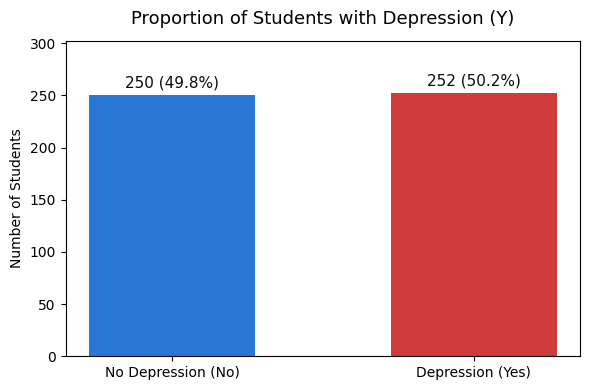

In [ ]:
COLOR_NO = "#2a78d6" # Blue
COLOR_YES = "#d03b3b" # Red

counts = df["Depression"].map({1: "Depression (Yes)", 0: "No Depression (No)"}).value_counts()
counts = counts.reindex(["No Depression (No)", "Depression (Yes)"])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[COLOR_NO, COLOR_YES], width=0.55)

for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val + 5, f"{val} ({pct:.1f}%)",
            ha="center", va="bottom", fontsize=11, color="#0b0b0b")

ax.set_title("Proportion of Students with Depression (Y)", fontsize=13, pad=12)
ax.set_ylabel("Number of Students")
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(False) # Turn off grid for this specific plot
plt.tight_layout()
plt.show()

**5.2 ตัวแปรเชิงปริมาณ เทียบกับ Depression**

ใช้ข้อมูลทั้งชุด (df) เพื่อการเล่าเรื่อง/สำรวจข้อมูล ไม่เกี่ยวกับการ fit โมเดล

/tmp/ipykernel_1865/1501663145.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
/tmp/ipykernel_1865/1501663145.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
/tmp/ipykernel_1865/1501663145.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
/tmp/ipykernel_1865/1501663145.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has

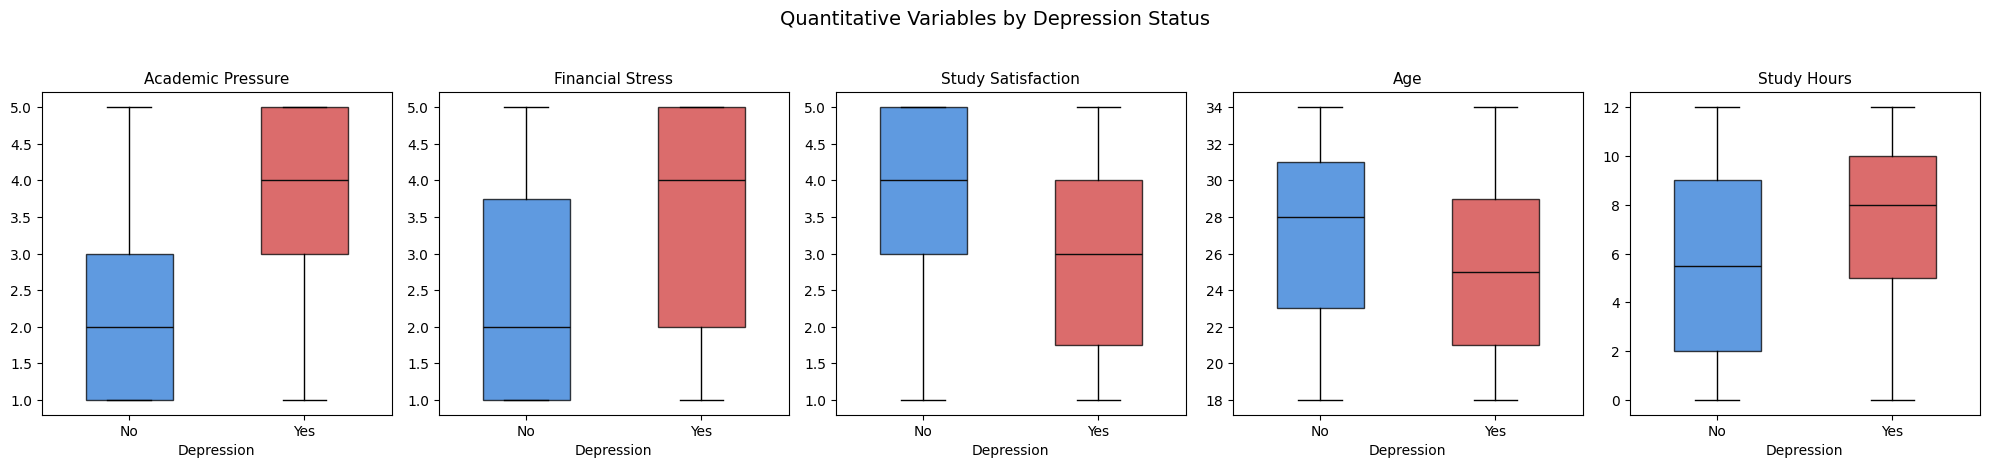

In [ ]:
quant_plot_vars = ["Academic Pressure", "Financial Stress", "Study Satisfaction", "Age", "Study Hours"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

for ax, var in zip(axes, quant_plot_vars):
    data_no = df.loc[df["Depression"] == 0, var]
    data_yes = df.loc[df["Depression"] == 1, var]
    bp = ax.boxplot([data_no, data_yes], labels=["No", "Yes"], patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], [COLOR_NO, COLOR_YES]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#0b0b0b")
    ax.set_title(var, fontsize=11)
    ax.set_xlabel("Depression")

fig.suptitle("Quantitative Variables by Depression Status", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**5.3 ตัวแปรเชิงคุณภาพ เทียบกับ Depression (สัดส่วน 100%)**

/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1865/1779698153.py:21: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) DejaVu Sans

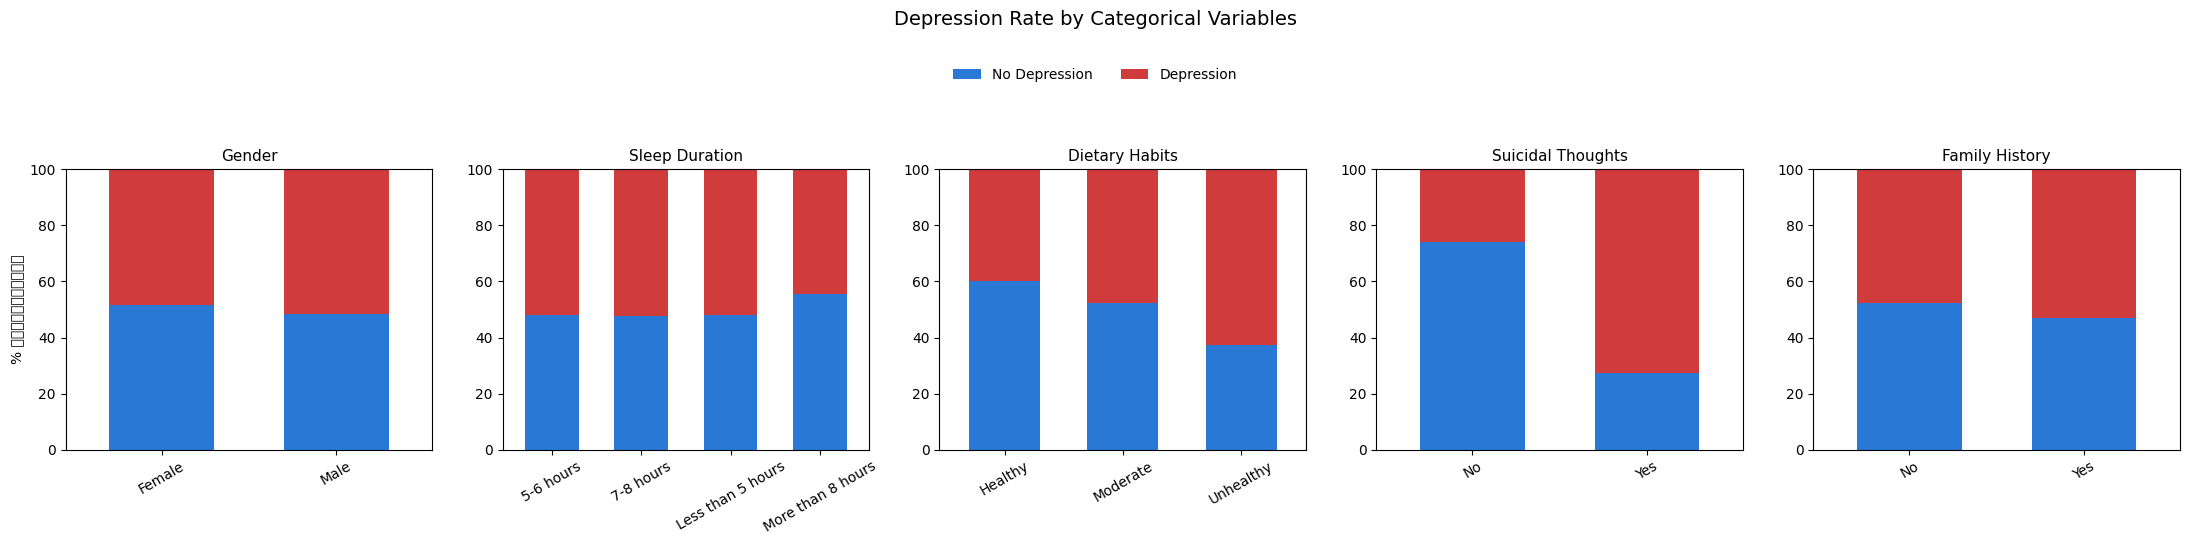

In [ ]:
qual_plot_vars = ["Gender", "Sleep Duration", "Dietary Habits",
                   "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]
qual_plot_labels = ["Gender", "Sleep Duration", "Dietary Habits", "Suicidal Thoughts", "Family History"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, var, label in zip(axes, qual_plot_vars, qual_plot_labels):
    tab = pd.crosstab(df[var], df["Depression"], normalize="index") * 100
    tab = tab.rename(columns={0: "No", 1: "Yes"})[["No", "Yes"]]
    tab.plot(kind="bar", stacked=True, ax=ax, color=[COLOR_NO, COLOR_YES], width=0.6, legend=False)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("% ของนักศึกษา" if var == qual_plot_vars[0] else "")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False) # Turn off grid for this specific plot

handles = [Patch(facecolor=COLOR_NO, label="No Depression"), Patch(facecolor=COLOR_YES, label="Depression")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.1), frameon=False)
fig.suptitle("Depression Rate by Categorical Variables", fontsize=14, y=1.2)
plt.tight_layout()
plt.show()

**5.4 p-value ของแต่ละตัวแปร (ผลจากหัวข้อ 6)**

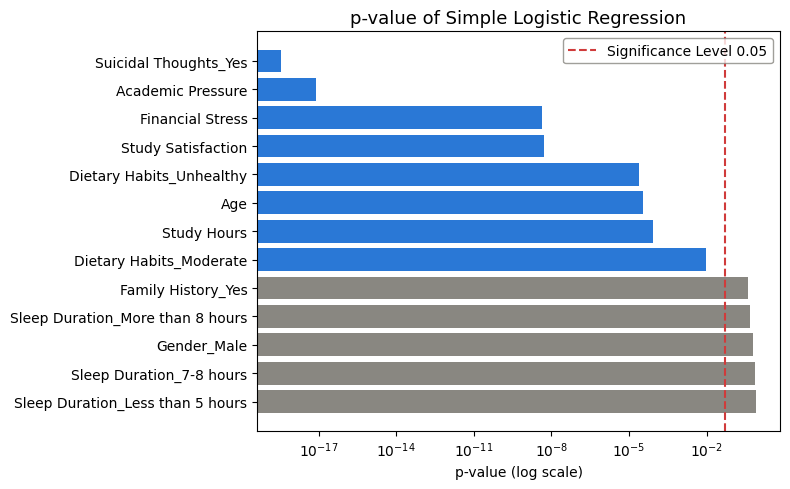

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define colors for plots (already defined in previous cells but ensure they are here too)
COLOR_NO = "#2a78d6" # Blue
COLOR_YES = "#d03b3b" # Red
COLOR_MUTED = "#898781" # Gray for muted/non-significant elements

# Re-create the detailed results list with numeric p-values
detailed_results = [
    {"Variable": r["Variable"], "p-value": r["p-value"]}
    for r in num_results
]

for col, prefix in [
    ("Gender", "Gender"),
    ("Sleep Duration", "Sleep Duration"),
    ("Dietary Habits", "Dietary Habits"),
    ("Have you ever had suicidal thoughts ?", "Suicidal Thoughts"),
    ("Family History of Mental Illness", "Family History"),
]:
    train_dummy = pd.get_dummies(x_train_full[col], prefix=prefix, drop_first=True)
    train_dummy = sm.add_constant(train_dummy).astype(int)
    r = sm.Logit(y_train, train_dummy).fit(disp=0)
    dummy_pvals = r.pvalues.drop("const")
    for dummy_name, pval in dummy_pvals.items():
        detailed_results.append({"Variable": dummy_name, "p-value": pval})

# 'detailed_results' list contains dictionaries with numeric p-values. Use this to construct a new DataFrame for plotting.
plot_df_numeric = pd.DataFrame(detailed_results)

# Add a column to indicate significance based on the numeric p-value
plot_df_numeric["is_significant"] = plot_df_numeric["p-value"] < 0.05

# Sort by numeric p-value in ascending order to place more significant variables at the top
# Resetting the index ensures that `iloc[i]` corresponds to `bars[i]`
plot_df_numeric = plot_df_numeric.sort_values("p-value", ascending=True).reset_index(drop=True)

# Define colors for the bars based on significance
colors_p = [COLOR_NO if sig else COLOR_MUTED for sig in plot_df_numeric["is_significant"]]

fig, ax = plt.subplots(figsize=(8, 5))
# Plot horizontal bars using the 'Variable' names and numeric 'p-value'
bars = ax.barh(plot_df_numeric["Variable"], plot_df_numeric["p-value"], color=colors_p)

# Add a vertical line for the significance level (0.05)
ax.axvline(0.05, color=COLOR_YES, linestyle="--", linewidth=1.5, label="Significance Level 0.05")

# Set the x-axis to a logarithmic scale for better visualization of small p-values
ax.set_xscale("log")
ax.set_xlabel("p-value (log scale)")
ax.set_title("p-value of Simple Logistic Regression", fontsize=13)

# Invert the y-axis to have the most significant variables (smallest p-values) at the top
ax.invert_yaxis()

# Adjust legend position and add a frame
ax.legend(loc="upper right", frameon=True, edgecolor="#898781", facecolor="white")

# Remove grid lines
ax.grid(False)

plt.tight_layout()
os.makedirs('figures/', exist_ok=True) # Ensure 'figures' directory exists before saving
plt.savefig("figures/04_pvalue_chart.png", dpi=200, bbox_inches="tight")
plt.show()

**5.5 ทิศทางผลของตัวแปรต่อโอกาสเกิด Depression (Coefficient, โมเดลรวม)**

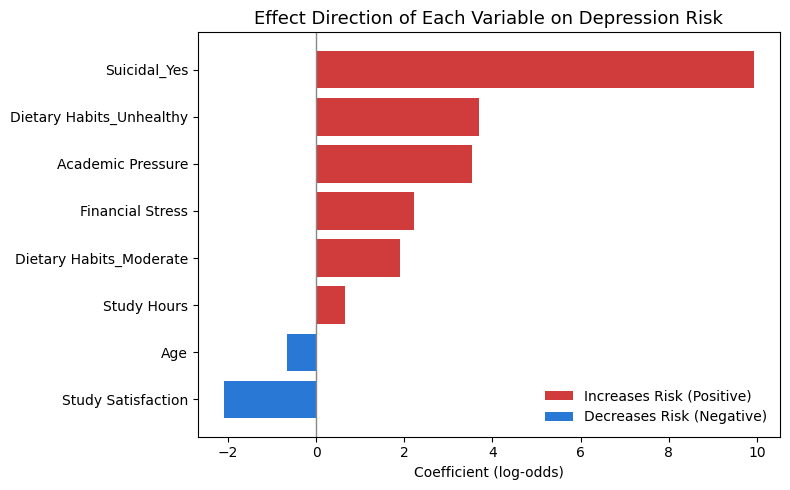

In [ ]:
COLOR_NO = "#2a78d6" # Blue
COLOR_YES = "#d03b3b" # Red
COLOR_POS = COLOR_YES # For positive coefficients (increase risk)
COLOR_NEG = COLOR_NO # For negative coefficients (decrease risk)

# Code to define interpretation_table (previously in cell y1vsHzIR9rqh)
odds_ratio = np.exp(result.params)
pct_change_odds = 100 * (np.exp(result.params) - 1)

interpretation_table = pd.DataFrame({
    "Coefficient": result.params,
    "Odds Ratio": odds_ratio,
    "% change in odds": pct_change_odds,
    "p-value": result.pvalues
})
interpretation_table = interpretation_table.drop("const")
interpretation_table["นัยสำคัญ (p<0.05)"] = interpretation_table["p-value"] < 0.05

plot_df2 = interpretation_table.copy().sort_values("Coefficient")
colors_c = [COLOR_POS if c > 0 else COLOR_NEG for c in plot_df2["Coefficient"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df2.index, plot_df2["Coefficient"], color=colors_c)
ax.axvline(0, color="#898781", linewidth=1)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Effect Direction of Each Variable on Depression Risk", fontsize=13)

legend_elems = [Patch(facecolor=COLOR_POS, label="Increases Risk (Positive)"),
                Patch(facecolor=COLOR_NEG, label="Decreases Risk (Negative)")]
ax.legend(handles=legend_elems, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

**5.6 ROC Curve — ประสิทธิภาพของตัวแบบ (เสริม AUC)**

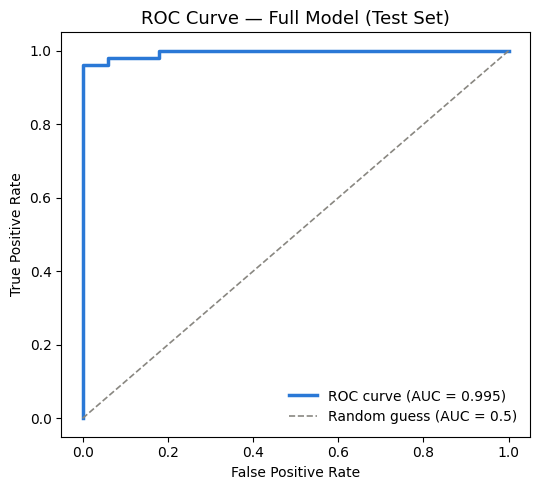

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=COLOR_NO, linewidth=2.5, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color=COLOR_MUTED, linestyle="--", linewidth=1.2, label="Random guess (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Full Model (Test Set)", fontsize=13)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
os.makedirs("figures/", exist_ok=True)
plt.savefig("figures/07_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()